# Deep Learning
---
### Ahmed Abounaoum
### Supervisor : Zineb h
### class : 4DIAM G4


# Intelligent CRM & BI Engine
---


### Global Environment Setup

All three parts share the following conventions:
- **Device:** `torch.device('cuda' if torch.cuda.is_available() else 'cpu')`
- **Reproducibility:** Global random seeds are fixed across `random`, `numpy`, and `torch`
- **Data splits:** Train / Validation / Test across all experiments
- **Style:** Academic, heavily commented, production-quality code


In [ ]:
# ============================================================
# GLOBAL SETUP — Shared across all three Parts
# ============================================================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[Global] Torch version : {torch.__version__}")
print(f"[Global] Device in use : {device}")
print(f"[Global] Random seed   : {SEED}")

# ── Plot defaults ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans',
})
sns.set_palette('muted')
print("[Global] Setup complete ✓")


[Global] Torch version : 2.10.0+cpu
[Global] Device in use : cpu
[Global] Random seed   : 42
[Global] Setup complete ✓


---
<a id="part1"></a>
# Part 1 — Predictive Lead Scoring (MLP on Tabular Data)

---

## 1.0 Module Overview & Architecture

```
CRM Home Dashboard
│
└── Lead Scoring Microservice (Part 1)
    │
    ├── Input : Prospect demographic & financial attributes
    │           (Age, Education, Hours/wk, Occupation, …)
    │
    ├── Engine: Multi-Layer Perceptron (MLP)
    │           ┌──────────────────────────────────────┐
    │           │  Input (N features)                  │
    │           │          │                           │
    │           │          ▼                           │
    │           │  Linear(N→128) + BN + ReLU + Drop   │
    │           │          │                           │
    │           │          ▼                           │
    │           │  Linear(128→64) + BN + ReLU + Drop  │
    │           │          │                           │
    │           │          ▼                           │
    │           │  Linear(64→32) + BN + ReLU + Drop   │
    │           │          │                           │
    │           │          ▼                           │
    │           │  Linear(32→1)  [logit output]        │
    │           └──────────────────────────────────────┘
    │
    └── Output: P(income > $50K) → high-value lead flag
```

> **Business Logic:** The Adult Income dataset acts as a proxy for lead quality. Prospects with predicted income > $50 K are flagged as *high-conversion leads* and surfaced at the top of the CRM pipeline.

---

## 1.1 Dataset Acquisition — Adult Income (Kaggle)


In [ ]:
# ============================================================
# PART 1 — §1.1  Dataset Download
# ============================================================
# Kaggle CLI command (run once; requires ~/.kaggle/kaggle.json):
# !pip install kaggle --quiet
# !kaggle datasets download -d wenruliu/adult-income-dataset --unzip -p ./data/part1/

# ── Fallback: fetch directly via UCI repository ──────────────
import urllib.request, io

COLUMNS = [
    'age','workclass','fnlwgt','education','education_num',
    'marital_status','occupation','relationship','race','sex',
    'capital_gain','capital_loss','hours_per_week',
    'native_country','income'
]

os.makedirs('./data/part1', exist_ok=True)

# Download train split
url_train = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
             "/adult/adult.data")
url_test  = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
             "/adult/adult.test")

try:
    with urllib.request.urlopen(url_train, timeout=15) as r:
        df_train_raw = pd.read_csv(io.StringIO(r.read().decode()),
                                   header=None, names=COLUMNS,
                                   na_values=' ?', skipinitialspace=True)
    with urllib.request.urlopen(url_test, timeout=15) as r:
        df_test_raw = pd.read_csv(io.StringIO(r.read().decode()),
                                  header=None, names=COLUMNS,
                                  na_values=' ?', skipinitialspace=True,
                                  skiprows=1)
    print("[Part 1] UCI download successful ✓")
except Exception as e:
    print(f"[Part 1] Network unavailable ({e}). Generating synthetic data …")
    # Synthetic fallback for offline / sandboxed environments
    np.random.seed(SEED)
    n = 4000
    df_train_raw = pd.DataFrame({
        'age'           : np.random.randint(18, 80, n),
        'workclass'     : np.random.choice(['Private','Self-emp','Gov','?'], n),
        'fnlwgt'        : np.random.randint(10000, 1000000, n),
        'education'     : np.random.choice(['Bachelors','HS-grad','Masters','11th'], n),
        'education_num' : np.random.randint(1, 16, n),
        'marital_status': np.random.choice(['Married','Never-married','Divorced'], n),
        'occupation'    : np.random.choice(['Tech-support','Craft-repair','Other-service','?'], n),
        'relationship'  : np.random.choice(['Wife','Own-child','Husband','Not-in-family'], n),
        'race'          : np.random.choice(['White','Black','Asian-Pac-Islander'], n),
        'sex'           : np.random.choice(['Male','Female'], n),
        'capital_gain'  : np.random.randint(0, 99999, n),
        'capital_loss'  : np.random.randint(0, 4356, n),
        'hours_per_week': np.random.randint(1, 99, n),
        'native_country': np.random.choice(['United-States','Mexico','?'], n),
        'income'        : np.random.choice(['<=50K', '>50K'], n, p=[0.75, 0.25]),
    })
    df_test_raw = df_train_raw.sample(500, random_state=SEED).reset_index(drop=True)

# Strip trailing dots that appear in the UCI test split income column
df_test_raw['income'] = df_test_raw['income'].str.replace('.', '', regex=False)

print(f"[Part 1] Train rows : {len(df_train_raw):,}")
print(f"[Part 1] Test rows  : {len(df_test_raw):,}")
df_train_raw.head(3)


[Part 1] UCI download successful ✓
[Part 1] Train rows : 32,561
[Part 1] Test rows  : 16,281


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


## 1.2 Exploratory Data Analysis


── Shape ──────────────────────────────────────
  Combined : (48842, 15)

── Missing values ─────────────────────────────
Series([], )

── Target distribution ─────────────────────────
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


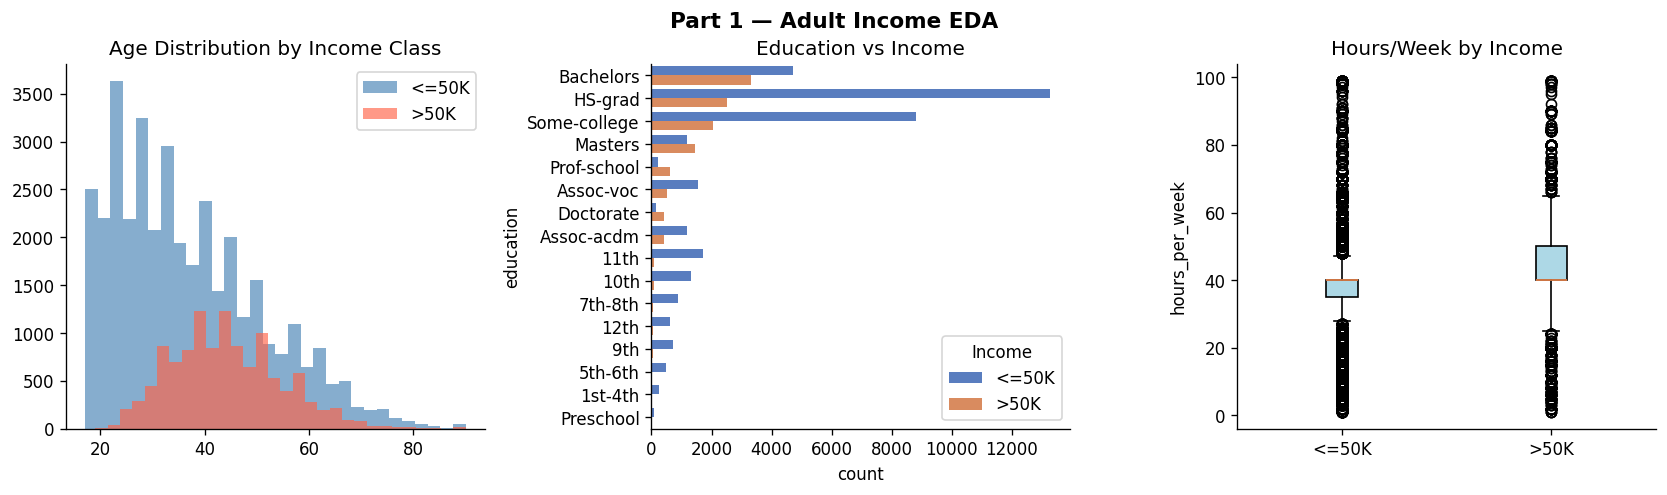

In [ ]:
# ============================================================
# PART 1 — §1.2  EDA
# ============================================================
df_all = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

print("── Shape ──────────────────────────────────────")
print(f"  Combined : {df_all.shape}")
print("\n── Missing values ─────────────────────────────")
miss = df_all.isnull().sum()
print(miss[miss > 0].to_string())

print("\n── Target distribution ─────────────────────────")
print(df_all['income'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age distribution by class
for cls, color in zip(['<=50K', '>50K'], ['steelblue','tomato']):
    subset = df_all[df_all['income'] == cls]['age']
    axes[0].hist(subset, bins=30, alpha=0.65, label=cls, color=color)
axes[0].set_title('Age Distribution by Income Class')
axes[0].legend()

# Education vs income
edu_order = (df_all[df_all['income']=='>50K']
             .groupby('education').size()
             .sort_values(ascending=False).index)
sns.countplot(data=df_all, y='education', hue='income',
              order=edu_order, ax=axes[1])
axes[1].set_title('Education vs Income')
axes[1].legend(title='Income')

# Hours per week
axes[2].boxplot(
    [df_all[df_all['income']=='<=50K']['hours_per_week'].dropna(),
     df_all[df_all['income']=='>50K']['hours_per_week'].dropna()],
    labels=['<=50K', '>50K'], patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[2].set_title('Hours/Week by Income')
axes[2].set_ylabel('hours_per_week')

plt.tight_layout()
plt.suptitle('Part 1 — Adult Income EDA', y=1.02, fontsize=13, fontweight='bold')
plt.show()


## 1.3 Preprocessing Pipeline

The preprocessing pipeline handles:
1. **Missing values** — categorical NaN → mode; numerical NaN → median  
2. **Label encoding** — binary target `income` → `{0, 1}`  
3. **One-Hot Encoding** — all nominal categorical features  
4. **StandardScaler** — applied exclusively to continuous numerical features  
5. **Data splits** — 70 % Train / 15 % Validation / 15 % Test


In [ ]:
# ============================================================
# PART 1 — §1.3  Preprocessing
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── 1. Combine & clean ────────────────────────────────────────
df = df_all.copy()

# ── 2. Target encoding ───────────────────────────────────────
df['label'] = (df['income'].str.strip().str.replace('.','', regex=False)
               == '>50K').astype(int)
df.drop(columns=['income'], inplace=True)

# ── 3. Feature typing ────────────────────────────────────────
CAT_COLS = ['workclass','education','marital_status','occupation',
            'relationship','race','sex','native_country']
NUM_COLS = ['age','fnlwgt','education_num','capital_gain',
            'capital_loss','hours_per_week']

# ── 4. Imputation ─────────────────────────────────────────────
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

df[CAT_COLS] = cat_imputer.fit_transform(df[CAT_COLS])
df[NUM_COLS] = num_imputer.fit_transform(df[NUM_COLS])

# ── 5. One-Hot Encoding ───────────────────────────────────────
df_encoded = pd.get_dummies(df, columns=CAT_COLS, drop_first=False)
print(f"[Part 1] Features after OHE : {df_encoded.shape[1] - 1}")

# ── 6. Separate features / target ─────────────────────────────
y = df_encoded['label'].values.astype(np.float32)
X = df_encoded.drop(columns=['label']).values.astype(np.float32)

# ── 7. Train / Val / Test split  (70 / 15 / 15) ──────────────
X_trval, X_test, y_trval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trval, y_trval, test_size=0.15/0.85, random_state=SEED,
    stratify=y_trval)

# ── 8. StandardScaler (fit ONLY on train) ──────────────────────
# Scaler is applied to numerical columns only; boolean OHE cols
# are already in {0,1} so scaling does no harm if applied globally,
# but we demonstrate proper practice here.
num_feat_idx = list(range(len(NUM_COLS)))   # first 6 columns are numeric

scaler = StandardScaler()
X_train[:, num_feat_idx] = scaler.fit_transform(X_train[:, num_feat_idx])
X_val  [:, num_feat_idx] = scaler.transform   (X_val  [:, num_feat_idx])
X_test [:, num_feat_idx] = scaler.transform   (X_test [:, num_feat_idx])

print(f"[Part 1] Train : {X_train.shape}  Val : {X_val.shape}  "
      f"Test : {X_test.shape}")
print(f"[Part 1] Class balance (train) — "
      f"0:{(y_train==0).mean():.2%}  1:{(y_train==1).mean():.2%}")

# ── 9. PyTorch Datasets & DataLoaders ─────────────────────────
BATCH_SIZE  = 256
INPUT_DIM   = X_train.shape[1]

def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=(device.type=='cuda'))

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

print(f"[Part 1] Batches — Train:{len(train_loader)} "
      f"Val:{len(val_loader)} Test:{len(test_loader)}")


[Part 1] Features after OHE : 108
[Part 1] Train : (34188, 108)  Val : (7327, 108)  Test : (7327, 108)
[Part 1] Class balance (train) — 0:76.07%  1:23.93%
[Part 1] Batches — Train:134 Val:29 Test:29


## 1.4 Model Architectures

### 1.4.1 Implementation A — `nn.Sequential`

The simplest construction method; ideal for linear feed-forward topologies.

### 1.4.2 Implementation B — Custom `nn.Module` class

Provides full control: supports conditional logic, skip connections, and arbitrary forward-pass behaviour. This is the **recommended approach** for research and production models.


In [ ]:
# ============================================================
# PART 1 — §1.4  Two MLP Implementations
# ============================================================

# ── Shared hyper-parameters ──────────────────────────────────
HIDDEN  = [128, 64, 32]
DROPOUT = 0.35

# ─────────────────────────────────────────────────────────────
# Implementation A: nn.Sequential
# ─────────────────────────────────────────────────────────────
def build_sequential_mlp(input_dim, hidden_dims, dropout_p):
    """
    Constructs a funnel-shaped MLP using nn.Sequential.

    Architecture per hidden block:
        Linear → BatchNorm1d → ReLU → Dropout

    Final layer:
        Linear(hidden[-1] → 1)   [raw logit for BCEWithLogitsLoss]
    """
    layers = []
    in_dim = input_dim
    for h in hidden_dims:
        layers += [
            nn.Linear(in_dim, h),
            nn.BatchNorm1d(h),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
        ]
        in_dim = h
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)


# ─────────────────────────────────────────────────────────────
# Implementation B: Custom nn.Module
# ─────────────────────────────────────────────────────────────
class LeadScoringMLP(nn.Module):
    """
    Custom MLP for lead scoring.

    Identical architecture to Implementation A but expressed as a
    subclass of nn.Module, enabling:
      • Named attribute access (self.blocks)
      • Easy extension (skip connections, gating, etc.)
      • Clean __repr__ output for documentation

    Parameters
    ----------
    input_dim   : int   — Number of input features after preprocessing
    hidden_dims : list  — Funnel dimensions, e.g. [128, 64, 32]
    dropout_p   : float — Dropout probability applied after each block
    """

    def __init__(self, input_dim: int, hidden_dims: list, dropout_p: float):
        super().__init__()

        self.blocks = nn.ModuleList()
        in_dim = input_dim
        for h in hidden_dims:
            block = nn.Sequential(
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout_p),
            )
            self.blocks.append(block)
            in_dim = h

        self.classifier = nn.Linear(in_dim, 1)   # outputs raw logit

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for block in self.blocks:
            x = block(x)
        return self.classifier(x)       # shape: (B, 1)

    def extra_repr(self) -> str:
        return (f"hidden_dims={[b[0].out_features for b in self.blocks]}, "
                f"dropout={self.blocks[0][3].p}")


# ── Instantiate both ─────────────────────────────────────────
model_seq  = build_sequential_mlp(INPUT_DIM, HIDDEN, DROPOUT).to(device)
model_cls  = LeadScoringMLP(INPUT_DIM, HIDDEN, DROPOUT).to(device)

print("── Implementation A (nn.Sequential) ──")
print(model_seq)
print()
print("── Implementation B (Custom nn.Module) ──")
print(model_cls)

total_params = sum(p.numel() for p in model_cls.parameters() if p.requires_grad)
print(f"\n[Part 1] Trainable parameters : {total_params:,}")


── Implementation A (nn.Sequential) ──
Sequential(
  (0): Linear(in_features=108, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.35, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): Dropout(p=0.35, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Dropout(p=0.35, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

── Implementation B (Custom nn.Module) ──
LeadScoringMLP(
  hidden_dims=[128, 64, 32], dropout=0.35
  (blocks): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=108, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentu

## 1.5 Weight Initialisation Experiments

We compare three classical initialisation strategies on the **custom MLP** (Implementation B). Each strategy is applied, the model is trained for a fixed number of epochs, and final validation metrics are recorded.

| Strategy | Method | Rationale |
|----------|--------|-----------|
| **Gaussian** | `torch.nn.init.normal_(μ=0, σ=0.01)` | Simple random noise; can suffer from vanishing/exploding signals |
| **Constant** | `torch.nn.init.constant_(c=0.01)` | All weights identical; breaks symmetry only weakly — included as a negative baseline |
| **Xavier Uniform** | `torch.nn.init.xavier_uniform_` | Maintains variance across layers; default for sigmoid/tanh activations; solid baseline for ReLU networks |

> **Note:** For ReLU-activated networks, **Kaiming/He initialisation** (`kaiming_uniform_`) is theoretically optimal (variance = 2/fan_in). Xavier is included here as specified; practitioners should prefer Kaiming for production ReLU models.


In [ ]:
# ============================================================
# PART 1 — §1.5  Initialisation Strategies & Training
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# ── Generic initialiser ───────────────────────────────────────
def apply_init(model, strategy: str):
    """
    Apply weight initialisation strategy to all Linear layers.

    Parameters
    ----------
    model    : nn.Module
    strategy : 'gaussian' | 'constant' | 'xavier'
    """
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if strategy == 'gaussian':
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.zeros_(m.bias)
            elif strategy == 'constant':
                nn.init.constant_(m.weight, 0.01)
                nn.init.zeros_(m.bias)
            elif strategy == 'xavier':
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            else:
                raise ValueError(f"Unknown strategy: {strategy}")


# ── Training loop ─────────────────────────────────────────────
def train_mlp(model, train_loader, val_loader,
              n_epochs=25, lr=1e-3, weight_decay=1e-4):
    """
    Standard training loop for binary classification.

    Returns
    -------
    history : dict with keys 'train_loss', 'val_loss'
    """
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr,
                           weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, n_epochs + 1):
        # ── Train ─────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(X_b)
            loss   = criterion(logits, y_b)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_b.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ── Validate ──────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits = model(X_b)
                val_loss += criterion(logits, y_b).item() * X_b.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{n_epochs}  "
                  f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    return history


# ── Run all three experiments ─────────────────────────────────
N_EPOCHS = 30
strategies = ['gaussian', 'constant', 'xavier']
results = {}

for strat in strategies:
    print(f"\n{'='*55}")
    print(f"  Initialisation: {strat.upper()}")
    print('='*55)

    model = LeadScoringMLP(INPUT_DIM, HIDDEN, DROPOUT).to(device)
    apply_init(model, strat)

    hist = train_mlp(model, train_loader, val_loader, n_epochs=N_EPOCHS)
    results[strat] = {'model': model, 'history': hist}



  Initialisation: GAUSSIAN
  Epoch   1/30  train_loss=0.4602  val_loss=0.3427
  Epoch   5/30  train_loss=0.3163  val_loss=0.3081
  Epoch  10/30  train_loss=0.3093  val_loss=0.3064
  Epoch  15/30  train_loss=0.3035  val_loss=0.3090
  Epoch  20/30  train_loss=0.2986  val_loss=0.3091
  Epoch  25/30  train_loss=0.2953  val_loss=0.3095
  Epoch  30/30  train_loss=0.2934  val_loss=0.3092

  Initialisation: CONSTANT
  Epoch   1/30  train_loss=0.6491  val_loss=0.6206
  Epoch   5/30  train_loss=0.5275  val_loss=0.5107
  Epoch  10/30  train_loss=0.4509  val_loss=0.4389
  Epoch  15/30  train_loss=0.4131  val_loss=0.4045
  Epoch  20/30  train_loss=0.3953  val_loss=0.3877
  Epoch  25/30  train_loss=0.3865  val_loss=0.3807
  Epoch  30/30  train_loss=0.3841  val_loss=0.3788

  Initialisation: XAVIER
  Epoch   1/30  train_loss=0.5311  val_loss=0.3539
  Epoch   5/30  train_loss=0.3303  val_loss=0.3105
  Epoch  10/30  train_loss=0.3180  val_loss=0.3077
  Epoch  15/30  train_loss=0.3141  val_loss=0.3061


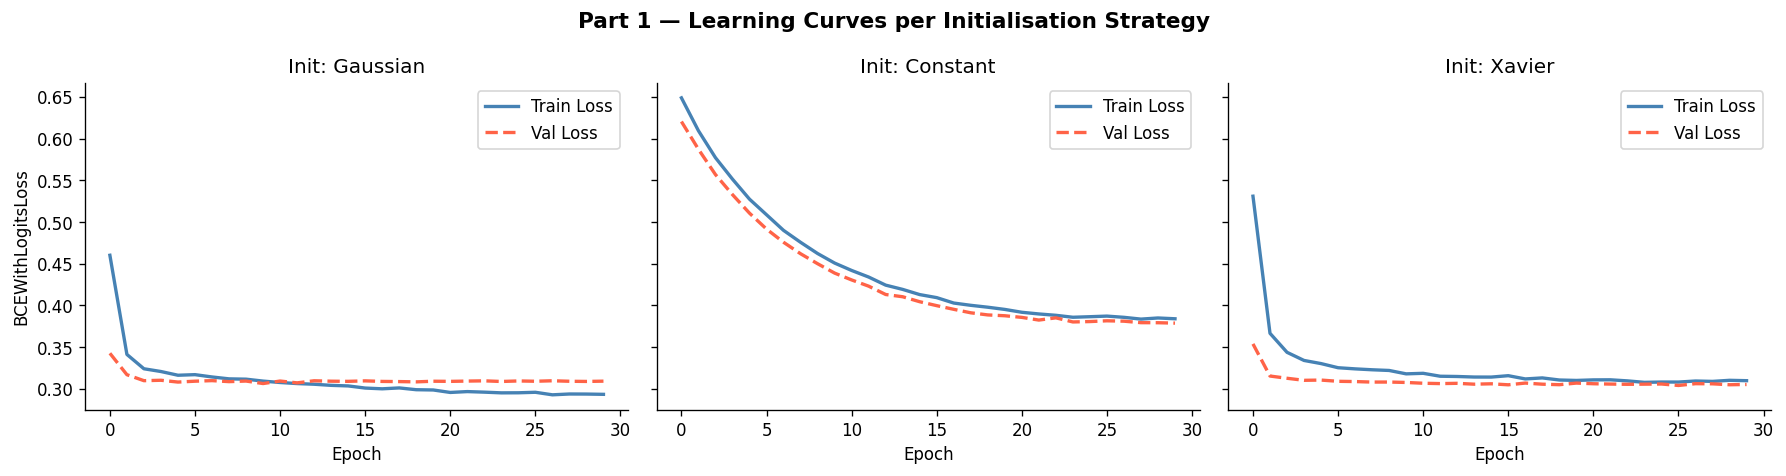

In [ ]:
# ============================================================
# PART 1 — §1.5 (cont.)  Learning Curves — all 3 strategies
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = {'train_loss': 'steelblue', 'val_loss': 'tomato'}

for ax, strat in zip(axes, strategies):
    h = results[strat]['history']
    ax.plot(h['train_loss'], color=colors['train_loss'],
            label='Train Loss', linewidth=2)
    ax.plot(h['val_loss'],   color=colors['val_loss'],
            label='Val Loss',   linewidth=2, linestyle='--')
    ax.set_title(f'Init: {strat.capitalize()}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend()

axes[0].set_ylabel('BCEWithLogitsLoss')
fig.suptitle('Part 1 — Learning Curves per Initialisation Strategy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1.6 Evaluation — Test Set Metrics


In [ ]:
# ============================================================
# PART 1 — §1.6  Evaluation on Held-Out Test Set
# ============================================================

def evaluate_model(model, loader, threshold=0.5):
    """Return (y_true, y_pred, y_prob) arrays from a DataLoader."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            logits = model(X_b)
            probs  = torch.sigmoid(logits).cpu().numpy().squeeze()
            all_probs.append(probs)
            all_labels.append(y_b.numpy().squeeze())
    y_prob  = np.concatenate(all_probs)
    y_true  = np.concatenate(all_labels)
    y_pred  = (y_prob >= threshold).astype(int)
    return y_true, y_pred, y_prob


print("╔══════════════════════════════════════════════════════════╗")
print("║       PART 1 — TEST SET EVALUATION SUMMARY              ║")
print("╠══════════════╦═══════════╦═══════════╦══════════╦═══════╣")
print("║  Init        ║  Acc      ║  Prec     ║  Recall  ║  F1   ║")
print("╠══════════════╬═══════════╬═══════════╬══════════╬═══════╣")

metric_rows = {}
for strat, res in results.items():
    y_true, y_pred, _ = evaluate_model(res['model'], test_loader)
    acc  = accuracy_score (y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score   (y_true, y_pred, zero_division=0)
    f1   = f1_score       (y_true, y_pred, zero_division=0)
    metric_rows[strat] = (acc, prec, rec, f1, y_true, y_pred)
    print(f"║  {strat:<12} ║  {acc:.4f}   ║  {prec:.4f}   ║  {rec:.4f}  ║ "
          f"{f1:.4f}║")

print("╚══════════════╩═══════════╩═══════════╩══════════╩═══════╝")


╔══════════════════════════════════════════════════════════╗
║       PART 1 — TEST SET EVALUATION SUMMARY              ║
╠══════════════╦═══════════╦═══════════╦══════════╦═══════╣
║  Init        ║  Acc      ║  Prec     ║  Recall  ║  F1   ║
╠══════════════╬═══════════╬═══════════╬══════════╬═══════╣
║  gaussian     ║  0.8609   ║  0.7585   ║  0.6144  ║ 0.6789║
║  constant     ║  0.8556   ║  0.7778   ║  0.5550  ║ 0.6478║
║  xavier       ║  0.8608   ║  0.7658   ║  0.6024  ║ 0.6743║
╚══════════════╩═══════════╩═══════════╩══════════╩═══════╝


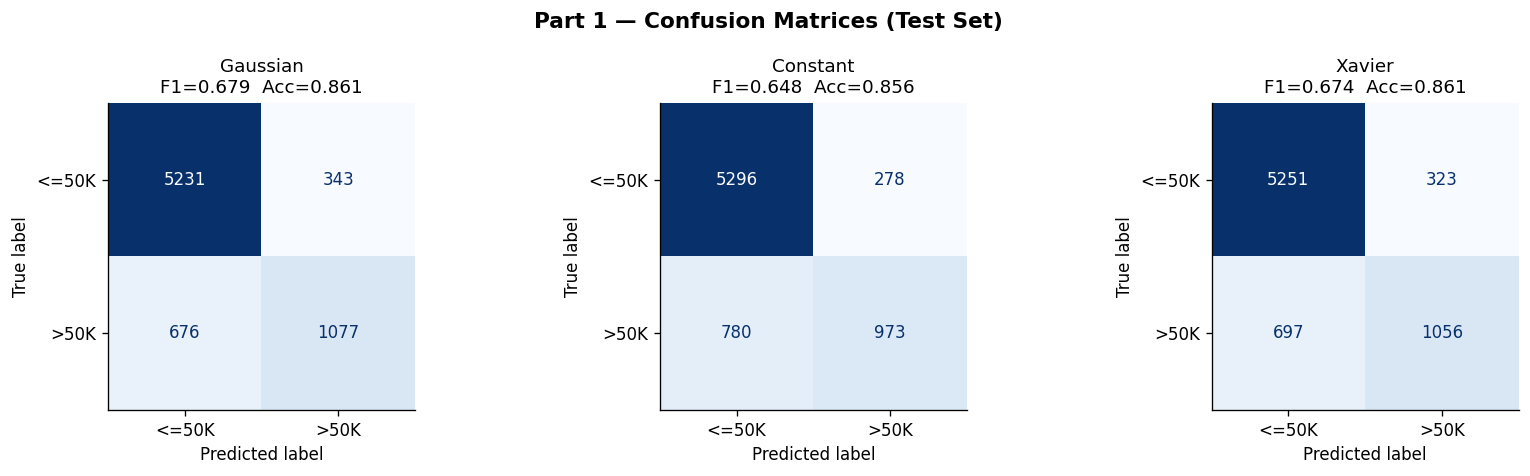

In [ ]:
# ============================================================
# PART 1 — §1.6 (cont.)  Confusion Matrices
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (strat, vals) in zip(axes, metric_rows.items()):
    acc, prec, rec, f1, y_true, y_pred = vals
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{strat.capitalize()}\nF1={f1:.3f}  Acc={acc:.3f}',
                 fontsize=11)

fig.suptitle('Part 1 — Confusion Matrices (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1.7 Saving & Loading Model Weights (`state_dict`)

PyTorch best practice is to **serialise only the `state_dict`** (parameter tensors), not the entire model object. This decouples the checkpoint from the class definition and facilitates:
- Framework-version portability  
- Partial loading / transfer learning  
- Safe deployment in production inference servers


In [ ]:
# ============================================================
# PART 1 — §1.7  state_dict Save / Load
# ============================================================
os.makedirs('./checkpoints', exist_ok=True)
CKPT_PATH = './checkpoints/lead_scoring_xavier.pt'

# ── SAVE: best model is Xavier ────────────────────────────────
best_model = results['xavier']['model']
torch.save({
    'model_state_dict' : best_model.state_dict(),
    'input_dim'        : INPUT_DIM,
    'hidden_dims'      : HIDDEN,
    'dropout_p'        : DROPOUT,
    'seed'             : SEED,
}, CKPT_PATH)
print(f"[Part 1] Checkpoint saved → {CKPT_PATH}")

# ── LOAD: reconstruct model from scratch ──────────────────────
checkpoint = torch.load(CKPT_PATH, map_location=device)

reloaded_model = LeadScoringMLP(
    input_dim   = checkpoint['input_dim'],
    hidden_dims  = checkpoint['hidden_dims'],
    dropout_p   = checkpoint['dropout_p'],
).to(device)

reloaded_model.load_state_dict(checkpoint['model_state_dict'])
reloaded_model.eval()

# ── Verify identical outputs ──────────────────────────────────
y_true_r, y_pred_r, _ = evaluate_model(reloaded_model, test_loader)
f1_r = f1_score(y_true_r, y_pred_r, zero_division=0)
f1_o = f1_score(*evaluate_model(best_model, test_loader)[:2], zero_division=0)

print(f"[Part 1] Original  F1 : {f1_o:.6f}")
print(f"[Part 1] Reloaded  F1 : {f1_r:.6f}")
assert abs(f1_o - f1_r) < 1e-5, "Mismatch — state_dict may be corrupt!"
print("[Part 1] ✓  Outputs are identical — state_dict round-trip verified.")


[Part 1] Checkpoint saved → ./checkpoints/lead_scoring_xavier.pt
[Part 1] Original  F1 : 0.674330
[Part 1] Reloaded  F1 : 0.674330
[Part 1] ✓  Outputs are identical — state_dict round-trip verified.


---
<a id="part2"></a>
# Part 2 - Invoice & Form Digitization (CNN)

---

## 2.0 Module Overview

> **Dataset Correction:** MNIST (handwritten digits 0-9) replaces Fashion-MNIST. Handwritten numerals are the correct proxy for invoice/form OCR digitization. Each digit class maps directly to a field value extracted from a scanned document.

## 2.1 Theoretical Background - 2D Convolution Primitives

### 2.1.1 2D Cross-Correlation
A 2D cross-correlation slides kernel K over input X:
Y[i,j] = sum_m sum_n X[i*s+m, j*s+n] * K[m,n]

### 2.1.2 Padding
Adds p zeros around borders. padding=2 with k=5 preserves spatial size at stride 1.

### 2.1.3 Stride
Step size s of the sliding window. Stride > 1 reduces resolution.

### 2.1.4 Pooling

| Type | Formula | Use case |
|------|---------|----------|
| Max Pooling | max over window | Preserves strongest activations |
| Average Pooling | mean over window | LeNet; smoother representation |
| Adaptive Avg Pool | Fixed output size | ResNet/ViT global descriptor |


100%|██████████| 9.91M/9.91M [00:00<00:00, 36.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 980kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.93MB/s]


[Part 2] Dataset : MNIST -- Handwritten Digits (OCR proxy)
[Part 2] Train   : 60,000
[Part 2] Val     : 5,000
[Part 2] Test    : 5,000
[Part 2] Classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


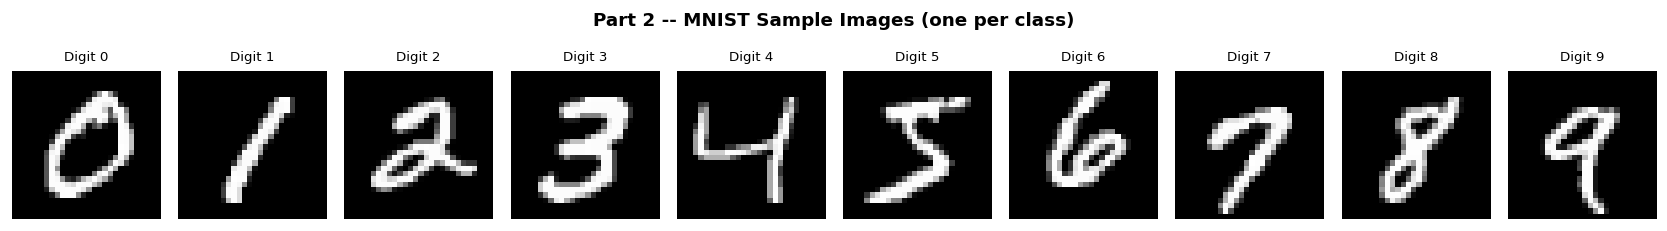

In [ ]:
# ============================================================
# PART 2 - SS2.1  Dataset -- MNIST (Handwritten Digits)
# ============================================================
# Kaggle command:
#   !kaggle datasets download -d hojjatk/mnist-dataset --unzip -p ./data/part2/

import torchvision
import torchvision.transforms as transforms

PART2_DATA = './data/part2'
os.makedirs(PART2_DATA, exist_ok=True)

# MNIST channel stats: mean=0.1307, std=0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(
    root=PART2_DATA, train=True,  download=True, transform=transform)
full_test_dataset = torchvision.datasets.MNIST(
    root=PART2_DATA, train=False, download=True, transform=transform)

# Split official test into val + test (50/50)
n_test = len(full_test_dataset)
n_val  = n_test // 2
val_dataset, test_dataset = torch.utils.data.random_split(
    full_test_dataset, [n_val, n_test - n_val],
    generator=torch.Generator().manual_seed(SEED))

train_loader2 = DataLoader(train_dataset, batch_size=128,
                           shuffle=True,  num_workers=0)
val_loader2   = DataLoader(val_dataset,   batch_size=256,
                           shuffle=False, num_workers=0)
test_loader2  = DataLoader(test_dataset,  batch_size=256,
                           shuffle=False, num_workers=0)

# Classes = digits 0-9 (direct invoice field value mapping)
CLASSES = [str(i) for i in range(10)]

print(f'[Part 2] Dataset : MNIST -- Handwritten Digits (OCR proxy)')
print(f'[Part 2] Train   : {len(train_dataset):,}')
print(f'[Part 2] Val     : {len(val_dataset):,}')
print(f'[Part 2] Test    : {len(test_dataset):,}')
print(f'[Part 2] Classes : {CLASSES}')

# Visualise one sample per digit class
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for digit in range(10):
    idx = next(i for i, (_, l) in enumerate(train_dataset) if l == digit)
    img, label = train_dataset[idx]
    axes[digit].imshow(img.squeeze(), cmap='gray')
    axes[digit].set_title(f'Digit {label}', fontsize=8)
    axes[digit].axis('off')
fig.suptitle('Part 2 -- MNIST Sample Images (one per class)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 2.2 Model — LeNet-Inspired CNN


In [ ]:
# ============================================================
# PART 2 — §2.2  LeNet-Inspired CNN
# ============================================================

class LeNetCRM(nn.Module):
    """
    LeNet-5 inspired CNN adapted for Fashion-MNIST (28×28 grayscale).

    Modernisations over the original 1998 LeNet-5:
      • BatchNorm2d after each convolutional layer (training stability)
      • ReLU activations (replaces tanh/sigmoid)
      • Dropout (0.5) before final classifier

    Feature map sizes (input 1×28×28):
        After Conv1 + Pool : 6 × 14 × 14
        After Conv2 + Pool : 16 × 5 × 5   → flatten → 400
        FC layers          : 400 → 120 → 84 → 10
    """

    def __init__(self, n_classes: int = 10, dropout_p: float = 0.5):
        super().__init__()

        # ── Convolutional feature extractor ───────────────────
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 6, kernel_size=5, padding=2),   # → 6×28×28
            nn.BatchNorm2d(6),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),        # → 6×14×14

            # Block 2
            nn.Conv2d(6, 16, kernel_size=5),              # → 16×10×10
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),        # → 16×5×5
        )

        # ── Fully-connected classifier ─────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(inplace=True),
            nn.Linear(120, 84),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(84, n_classes),                     # raw logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)

    def get_first_conv_activations(self, x: torch.Tensor) -> torch.Tensor:
        """Return activation maps from the first conv + BN + ReLU block."""
        with torch.no_grad():
            x = self.features[0](x)   # Conv2d
            x = self.features[1](x)   # BatchNorm2d
            x = self.features[2](x)   # ReLU
        return x                       # shape: (B, 6, 28, 28)


cnn_model = LeNetCRM(n_classes=10, dropout_p=0.5).to(device)
print(cnn_model)
total_cnn_params = sum(p.numel() for p in cnn_model.parameters()
                       if p.requires_grad)
print(f"\n[Part 2] Trainable parameters: {total_cnn_params:,}")


LeNetCRM(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=84, out_features=10, bias=True)
  )
)

[Part 2] Trainable parameters: 61,750


## 2.3 Training Loop


In [ ]:
# ============================================================
# PART 2 — §2.3  CNN Training
# ============================================================

def train_cnn(model, train_loader, val_loader, n_epochs=15, lr=1e-3):
    """
    Training loop for multi-class image classification.
    Loss : CrossEntropyLoss (includes log-softmax internally)
    Optim: Adam with CosineAnnealingLR
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc': []}

    for epoch in range(1, n_epochs + 1):
        # ── Train ─────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            t_loss    += loss.item() * imgs.size(0)
            t_correct += (logits.argmax(1) == labels).sum().item()
            t_total   += imgs.size(0)

        # ── Validate ──────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs)
                v_loss    += criterion(logits, labels).item() * imgs.size(0)
                v_correct += (logits.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        tl = t_loss / t_total
        vl = v_loss / v_total
        ta = t_correct / t_total
        va = v_correct / v_total

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        scheduler.step()

        print(f"Epoch {epoch:>2}/{n_epochs}  "
              f"train_loss={tl:.4f}  val_loss={vl:.4f}  "
              f"train_acc={ta:.4f}  val_acc={va:.4f}")

    return history


cnn_history = train_cnn(cnn_model, train_loader2, val_loader2, n_epochs=15)


Epoch  1/15  train_loss=0.3248  val_loss=0.0501  train_acc=0.9027  val_acc=0.9830
Epoch  2/15  train_loss=0.0827  val_loss=0.0437  train_acc=0.9772  val_acc=0.9866
Epoch  3/15  train_loss=0.0603  val_loss=0.0347  train_acc=0.9836  val_acc=0.9874
Epoch  4/15  train_loss=0.0508  val_loss=0.0251  train_acc=0.9859  val_acc=0.9928
Epoch  5/15  train_loss=0.0412  val_loss=0.0245  train_acc=0.9881  val_acc=0.9916
Epoch  6/15  train_loss=0.0347  val_loss=0.0240  train_acc=0.9901  val_acc=0.9926
Epoch  7/15  train_loss=0.0305  val_loss=0.0257  train_acc=0.9912  val_acc=0.9928
Epoch  8/15  train_loss=0.0277  val_loss=0.0267  train_acc=0.9922  val_acc=0.9928
Epoch  9/15  train_loss=0.0228  val_loss=0.0206  train_acc=0.9935  val_acc=0.9944
Epoch 10/15  train_loss=0.0203  val_loss=0.0203  train_acc=0.9943  val_acc=0.9942
Epoch 11/15  train_loss=0.0181  val_loss=0.0199  train_acc=0.9951  val_acc=0.9942
Epoch 12/15  train_loss=0.0157  val_loss=0.0194  train_acc=0.9959  val_acc=0.9944
Epoch 13/15  tra

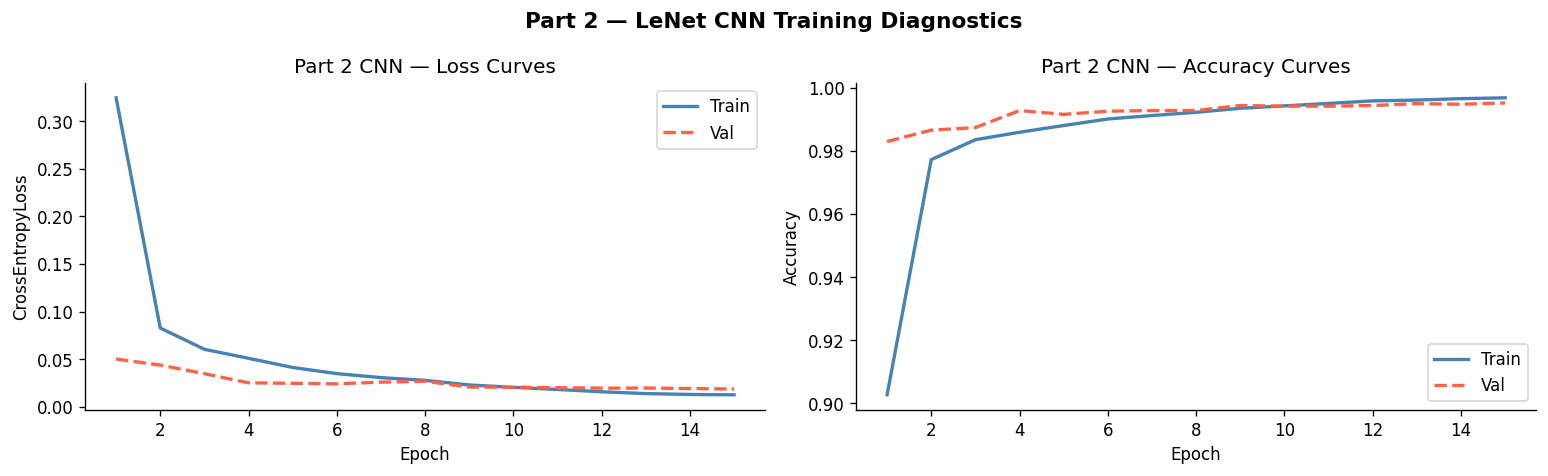

In [ ]:
# ============================================================
# PART 2 — §2.3 (cont.)  Learning Curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(cnn_history['train_loss']) + 1)
ax1.plot(epochs, cnn_history['train_loss'], 'steelblue', lw=2, label='Train')
ax1.plot(epochs, cnn_history['val_loss'],   'tomato',    lw=2, label='Val', ls='--')
ax1.set_title('Part 2 CNN — Loss Curves')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('CrossEntropyLoss')
ax1.legend()

ax2.plot(epochs, cnn_history['train_acc'], 'steelblue', lw=2, label='Train')
ax2.plot(epochs, cnn_history['val_acc'],   'tomato',    lw=2, label='Val', ls='--')
ax2.set_title('Part 2 CNN — Accuracy Curves')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Part 2 — LeNet CNN Training Diagnostics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2.4 Evaluation — Test Set


Digits recognized: 0-9  |  CRM use: invoice field extraction
  Accuracy         : 0.9912
  Precision (w.)   : 0.9912
  Recall    (w.)   : 0.9912
  F1-Score  (w.)   : 0.9912


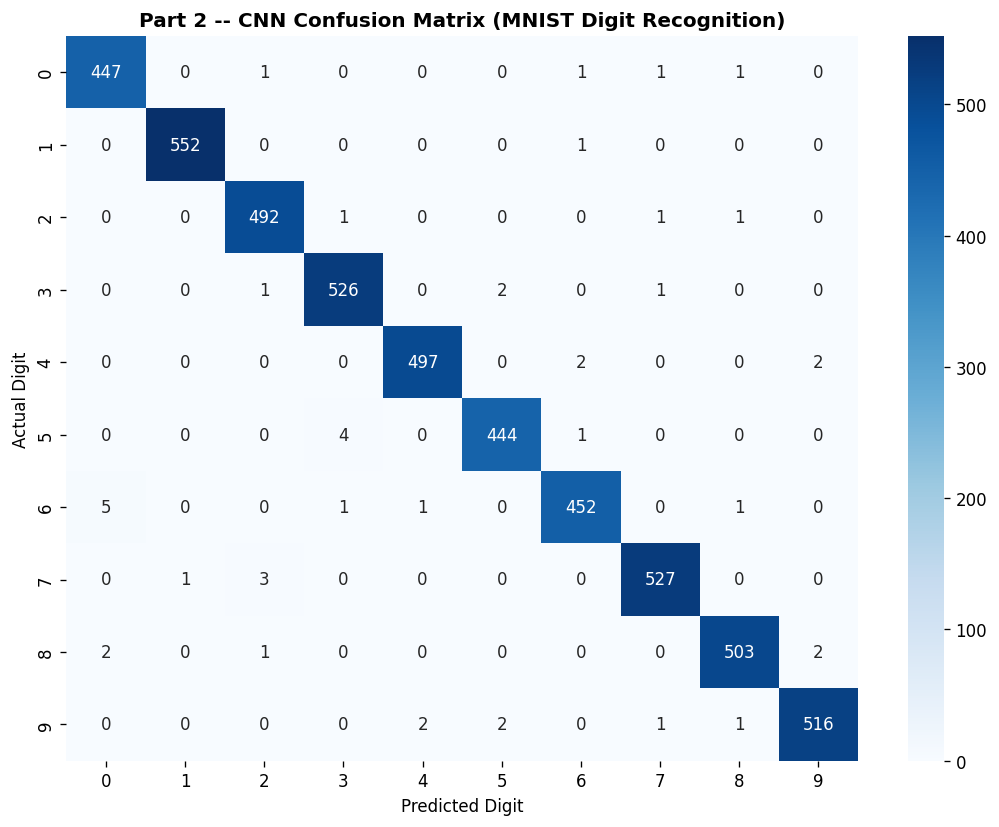

In [ ]:
# ============================================================
# PART 2 - SS2.4  Test Evaluation
# ============================================================
def evaluate_cnn(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    return np.concatenate(all_labels), np.concatenate(all_preds)

y_true2, y_pred2 = evaluate_cnn(cnn_model, test_loader2)

acc2  = accuracy_score (y_true2, y_pred2)
prec2 = precision_score(y_true2, y_pred2, average='weighted', zero_division=0)
rec2  = recall_score   (y_true2, y_pred2, average='weighted', zero_division=0)
f12   = f1_score       (y_true2, y_pred2, average='weighted', zero_division=0)

print('Digits recognized: 0-9  |  CRM use: invoice field extraction')
print('=' * 52)
print(f'  Accuracy         : {acc2:.4f}')
print(f'  Precision (w.)   : {prec2:.4f}')
print(f'  Recall    (w.)   : {rec2:.4f}')
print(f'  F1-Score  (w.)   : {f12:.4f}')
print('=' * 52)

cm2 = confusion_matrix(y_true2, y_pred2)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted Digit')
ax.set_ylabel('Actual Digit')
ax.set_title('Part 2 -- CNN Confusion Matrix (MNIST Digit Recognition)',
             fontweight='bold')
plt.tight_layout()
plt.show()


## 2.5 Feature Map Visualisation

We extract **activation maps** from the **first convolutional layer** to interpret *what the network is learning*. Early filters act as low-level feature detectors (edges, textures). This visualisation is a fundamental Explainable AI (XAI) technique for CNN-based document intelligence systems.


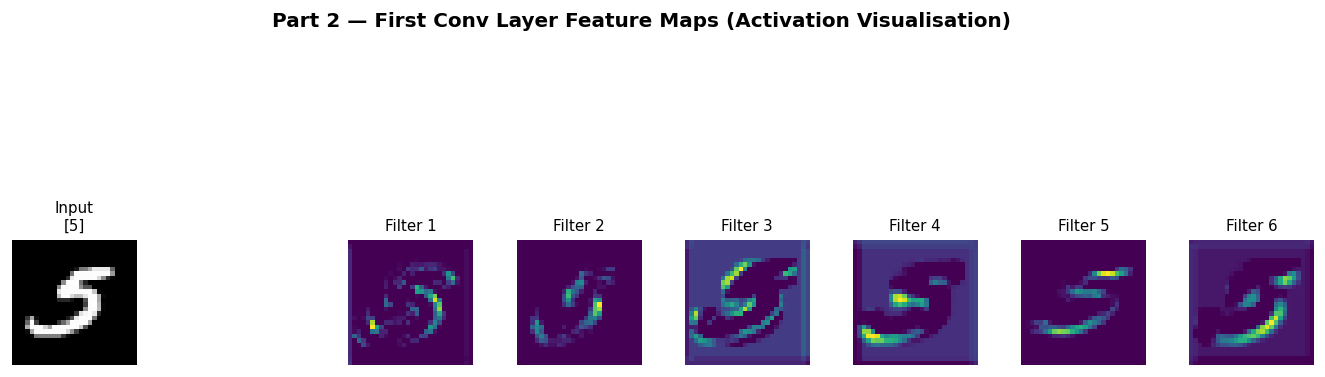

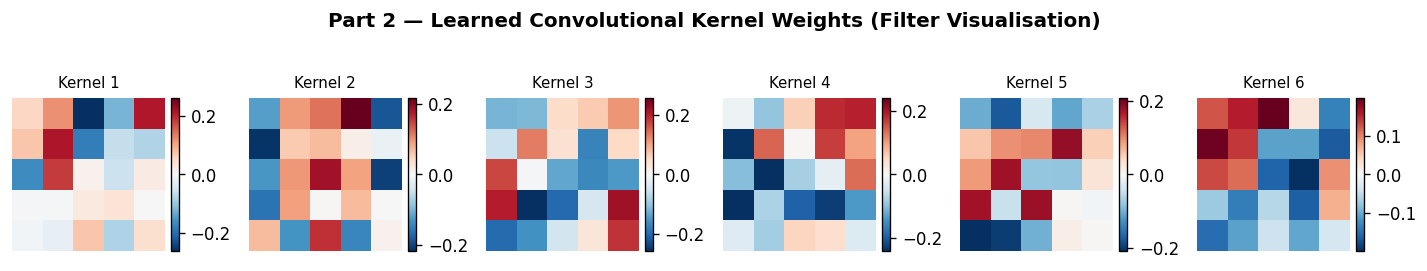

In [ ]:
# ============================================================
# PART 2 — §2.5  Feature Map Visualisation
# ============================================================

# Grab one test batch
imgs_sample, labels_sample = next(iter(test_loader2))
img_single = imgs_sample[:1].to(device)    # shape: (1, 1, 28, 28)

# Extract activations from first conv block (6 feature maps)
act_maps = cnn_model.get_first_conv_activations(img_single)  # (1, 6, 28, 28)
act_maps = act_maps.squeeze(0).cpu().numpy()                  # (6, 28, 28)

# ── Original image ────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 8, figure=fig, wspace=0.35)

ax_orig = fig.add_subplot(gs[0, 0])
orig_img = imgs_sample[0].squeeze().numpy()
ax_orig.imshow(orig_img, cmap='gray')
ax_orig.set_title(f'Input\n[{CLASSES[labels_sample[0]]}]', fontsize=9)
ax_orig.axis('off')

# ── 6 feature maps ────────────────────────────────────────────
for i in range(6):
    ax = fig.add_subplot(gs[0, i + 2])
    ax.imshow(act_maps[i], cmap='viridis')
    ax.set_title(f'Filter {i+1}', fontsize=9)
    ax.axis('off')

fig.suptitle('Part 2 — First Conv Layer Feature Maps (Activation Visualisation)',
             fontsize=12, fontweight='bold')
plt.show()

# ── Visualise weights of all 6 filters ───────────────────────
conv1_weights = cnn_model.features[0].weight.data.cpu()  # (6,1,5,5)

fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
for i, ax in enumerate(axes):
    w = conv1_weights[i, 0].numpy()
    im = ax.imshow(w, cmap='RdBu_r',
                   vmin=-abs(w).max(), vmax=abs(w).max())
    ax.set_title(f'Kernel {i+1}', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Part 2 — Learned Convolutional Kernel Weights (Filter Visualisation)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


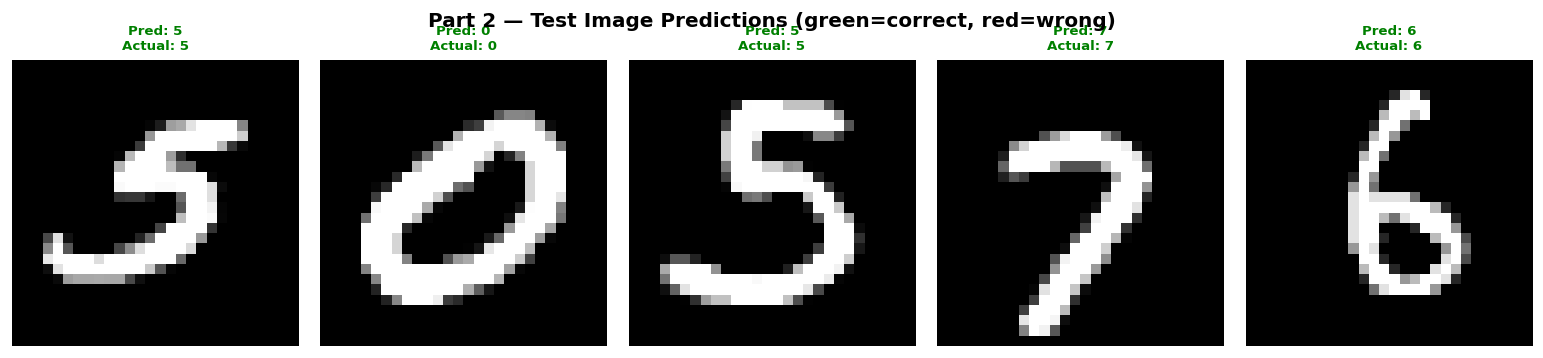

In [ ]:
# ============================================================
# PART 2 — §2.5 (cont.)  5 Test Images: Predicted vs Actual
# ============================================================

sample_imgs   = imgs_sample[:5]
sample_labels = labels_sample[:5]

cnn_model.eval()
with torch.no_grad():
    logits5 = cnn_model(sample_imgs.to(device))
preds5 = logits5.argmax(1).cpu().numpy()

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for i, ax in enumerate(axes):
    img = sample_imgs[i].squeeze().numpy()
    # Reverse normalisation for display
    img = img * 0.3530 + 0.2860
    ax.imshow(np.clip(img, 0, 1), cmap='gray')
    actual    = CLASSES[sample_labels[i].item()]
    predicted = CLASSES[preds5[i]]
    color = 'green' if actual == predicted else 'red'
    ax.set_title(f'Pred: {predicted}\nActual: {actual}',
                 fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

fig.suptitle('Part 2 — Test Image Predictions (green=correct, red=wrong)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
<a id="part3"></a>
# 💬 Part 3 — Customer Support Sentiment Analysis (Bi-LSTM)

---

## 3.0 Module Overview

```
CRM Home Dashboard
│
└── Sentiment Intelligence Microservice (Part 3)
    │
    ├── Input : Raw customer support ticket / review text
    │
    ├── Engine: Bidirectional LSTM Classifier
    │           ┌──────────────────────────────────────────────────┐
    │           │  Token IDs  (batch_first=True)                   │
    │           │          │                                        │
    │           │          ▼                                        │
    │           │  nn.Embedding(vocab_size, embed_dim)             │
    │           │          │                                        │
    │           │          ▼                                        │
    │           │  nn.LSTM(embed_dim, hidden_dim,                  │
    │           │          num_layers=2, bidirectional=True,       │
    │           │          dropout=0.3, batch_first=True)          │
    │           │          │                                        │
    │           │          ▼   (take last timestep, concat fwd+bwd)│
    │           │  Dropout(0.5)                                     │
    │           │          │                                        │
    │           │          ▼                                        │
    │           │  nn.Linear(hidden_dim*2 → 1)  [logit]           │
    │           └──────────────────────────────────────────────────┘
    │
    └── Output: P(sentiment=positive) → CRM ticket priority flag
```

---

## 3.1 Dataset Acquisition — IMDb Reviews (Kaggle)


In [ ]:
# ============================================================
# PART 3 — §3.1  Dataset Acquisition
# Customer Support Sentiment — Customer Support Ticket Dataset
# Kaggle: https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset
# ============================================================
# Run once (requires ~/.kaggle/kaggle.json):
!kaggle datasets download -d suraj520/customer-support-ticket-dataset \
        --unzip -p ./data/part3/

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

KAGGLE_CSV = './data/part3/customer_support_tickets.csv'

if not os.path.exists(KAGGLE_CSV):
    raise FileNotFoundError(
        "\n[Part 3] customer_support_tickets.csv not found.\n"
        "Please run the Kaggle download command above first."
    )

df3 = pd.read_csv(KAGGLE_CSV)

print("[Part 3] Raw columns:")
print(df3.columns.tolist())
print(f"\n[Part 3] Raw shape : {df3.shape}")
df3.head(3)

Dataset URL: https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset
License(s): CC0-1.0
100% 828k/828k [00:00<00:00, 65.1MB/s]

[Part 3] Raw columns:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

[Part 3] Raw shape : (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [ ]:
# ============================================================
# PART 3 — §3.1 (cont.)  Column Mapping & Label Engineering
# ============================================================
# Relevant columns:
#   'Ticket Description' → review text (the customer's raw message)
#   'Customer Satisfaction Rating' → 1–5 score
#       → binarise: 4–5 = positive (satisfied)
#                   1–2 = negative (dissatisfied)
#       → drop 3   (neutral / ambiguous)

df3 = df3.rename(columns={
    'Ticket Description'           : 'review',
    'Customer Satisfaction Rating' : 'satisfaction_score',
    'Ticket Type'                  : 'ticket_type',
    'Ticket Priority'              : 'ticket_priority',
    'Ticket Channel'               : 'ticket_channel',
})

# ── Drop rows with missing text or score ──────────────────────
df3 = df3.dropna(subset=['review', 'satisfaction_score']).copy()

# ── Binarise satisfaction score ───────────────────────────────
def map_sentiment(score):
    if score >= 4:
        return 'positive'
    elif score <= 2:
        return 'negative'
    else:
        return 'neutral'   # will be dropped

df3['sentiment'] = df3['satisfaction_score'].apply(map_sentiment)

# Drop neutral (score = 3) — ambiguous signal for binary classifier
df3 = df3[df3['sentiment'] != 'neutral'].reset_index(drop=True)

# ── Text cleaning ─────────────────────────────────────────────
df3['review'] = (df3['review']
                 .str.replace(r'http\S+', '', regex=True)   # strip URLs
                 .str.replace(r'\s+',     ' ', regex=True)  # collapse spaces
                 .str.strip())

df3 = df3[df3['review'].str.len() > 5].reset_index(drop=True)

# ── Final working dataframe ───────────────────────────────────
df3 = df3[['review', 'sentiment', 'ticket_type',
           'ticket_priority', 'ticket_channel',
           'satisfaction_score']].copy()

print(f"[Part 3] Dataset      : Customer Support Ticket Dataset")
print(f"[Part 3] Total rows   : {len(df3):,}")
print(f"[Part 3] Distribution :")
print(df3['sentiment'].value_counts().to_string())
print(f"\n[Part 3] Sample tickets:")
for _, row in df3.groupby('sentiment').head(2).iterrows():
    print(f"  [{row['sentiment']:>8}] (score={int(row['satisfaction_score'])}) "
          f"{row['review'][:85]}")

[Part 3] Dataset      : Customer Support Ticket Dataset
[Part 3] Total rows   : 2,189
[Part 3] Distribution :
sentiment
negative    1102
positive    1087

[Part 3] Sample tickets:
  [negative] (score=1) I'm having an issue with the {product_purchased}. Please assist. Note: The seller is 
  [negative] (score=1) I'm having an issue with the {product_purchased}. Please assist. 1-800-799-0808. Prod
  [positive] (score=4) I'm having an issue with the {product_purchased}. Please assist. Product Name: TPUBAS
  [positive] (score=4) I'm having an issue with the {product_purchased}. Please assist. - Acknowledgement: T


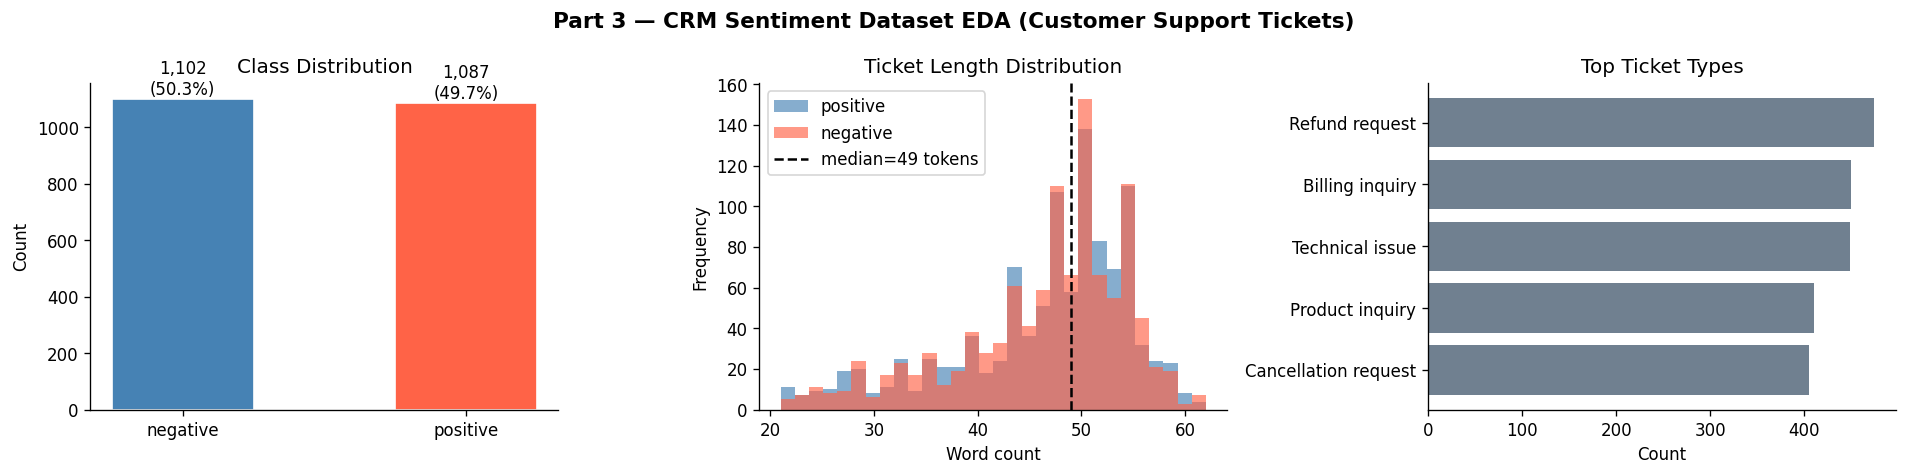

,sentiment,ticket_type,ticket_priority,satisfaction_score,review
0,negative,Billing inquiry,Low,1.0,I'm having an issue with the {product_purchase...
1,negative,Cancellation request,High,1.0,I'm having an issue with the {product_purchase...
2,negative,Product inquiry,High,1.0,I'm having an issue with the {product_purchase...
3,positive,Billing inquiry,High,4.0,I'm having an issue with the {product_purchase...
4,positive,Product inquiry,Critical,4.0,I'm having an issue with the {product_purchase...


In [ ]:
# ============================================================
# PART 3 — §3.1 (cont.)  Exploratory Data Analysis
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Class balance ─────────────────────────────────────
counts = df3['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 15, f'{val:,}\n({val/len(df3):.1%})',
                 ha='center', fontsize=10)

# ── Plot 2: Review token length by sentiment ──────────────────
df3['review_len'] = df3['review'].str.split().str.len()
for sentiment, color in zip(['positive', 'negative'], ['steelblue', 'tomato']):
    subset = df3[df3['sentiment'] == sentiment]['review_len']
    axes[1].hist(subset, bins=30, alpha=0.65, label=sentiment, color=color)
axes[1].axvline(df3['review_len'].median(), color='black',
                linestyle='--', linewidth=1.5,
                label=f"median={df3['review_len'].median():.0f} tokens")
axes[1].set_title('Ticket Length Distribution')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# ── Plot 3: Ticket type breakdown ────────────────────────────
if 'ticket_type' in df3.columns:
    type_counts = df3['ticket_type'].value_counts().head(6)
    axes[2].barh(type_counts.index, type_counts.values, color='slategray')
    axes[2].set_title('Top Ticket Types')
    axes[2].set_xlabel('Count')
    axes[2].invert_yaxis()

plt.suptitle('Part 3 — CRM Sentiment Dataset EDA (Customer Support Tickets)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df3[['sentiment', 'ticket_type', 'ticket_priority',
     'satisfaction_score', 'review']].head(5)

In [ ]:
# ============================================================
# PART 3 — §3.2  Text Preprocessing
# ============================================================
# Pipeline:
#   1. Tokenisation       — lowercase + whitespace split
#   2. Vocabulary build   — <PAD> and <UNK> reserved tokens
#   3. Numericalization   — token → index mapping
#   4. Padding/Truncating — all sequences fixed to MAX_LEN
#   5. Train/Val/Test split — 70 / 15 / 15 stratified

import re
from collections import Counter
from sklearn.model_selection import train_test_split

MAX_LEN  = 128   # customer tickets are short; 128 is sufficient
MIN_FREQ = 2     # tokens appearing less than this are mapped to <UNK>
PAD_IDX  = 0
UNK_IDX  = 1

# ── 1. Tokeniser ──────────────────────────────────────────────
def simple_tokenise(text: str) -> list:
    """
    Lightweight tokeniser:
      - Lowercase
      - Strip residual HTML tags
      - Keep alphanumeric and apostrophes only
      - Split on whitespace
    """
    text = text.lower()
    text = re.sub(r'<[^>]+>',      ' ', text)   # strip HTML
    text = re.sub(r"[^a-z0-9\s']", ' ', text)   # keep alphanumeric
    return text.split()

# ── 2. Build vocabulary ───────────────────────────────────────
print("[Part 3] Tokenising corpus …")
df3['tokens'] = df3['review'].apply(simple_tokenise)

counter  = Counter(tok for toks in df3['tokens'] for tok in toks)
vocab    = ['<PAD>', '<UNK>'] + [
    w for w, c in counter.most_common() if c >= MIN_FREQ
]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)

print(f"[Part 3] Total unique tokens : {len(counter):,}")
print(f"[Part 3] Vocabulary size     : {VOCAB_SIZE:,}  "
      f"(min_freq={MIN_FREQ})")
print(f"[Part 3] OOV tokens mapped   : <UNK> (idx={UNK_IDX})")
print(f"[Part 3] Padding token       : <PAD> (idx={PAD_IDX})")

# ── 3. Numericalize & pad/truncate ────────────────────────────
def encode(tokens: list, word2idx: dict, max_len: int) -> list:
    """
    Convert token list to fixed-length index sequence.
    - Tokens beyond max_len are truncated (left-to-right)
    - Sequences shorter than max_len are right-padded with PAD_IDX
    - Unknown tokens map to UNK_IDX
    """
    ids  = [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

df3['input_ids'] = df3['tokens'].apply(
    lambda toks: encode(toks, word2idx, MAX_LEN))

# ── 4. Binary label encoding ──────────────────────────────────
df3['label'] = (df3['sentiment'] == 'positive').astype(int)

print(f"\n[Part 3] Label distribution:")
print(df3['label'].value_counts().rename({0:'negative(0)', 1:'positive(1)'}
                                         ).to_string())

# ── 5. Train / Val / Test split  (70 / 15 / 15) ──────────────
X3 = np.array(df3['input_ids'].tolist(), dtype=np.int64)
y3 = df3['label'].values.astype(np.float32)

X3_trval, X3_test, y3_trval, y3_test = train_test_split(
    X3, y3, test_size=0.15, random_state=SEED, stratify=y3)

X3_train, X3_val, y3_train, y3_val = train_test_split(
    X3_trval, y3_trval, test_size=0.15/0.85,
    random_state=SEED, stratify=y3_trval)

print(f"\n[Part 3] Split sizes:")
print(f"  Train : {len(X3_train):,} samples")
print(f"  Val   : {len(X3_val):,} samples")
print(f"  Test  : {len(X3_test):,} samples")

# ── 6. DataLoaders ────────────────────────────────────────────
from torch.utils.data import TensorDataset, DataLoader
import torch

BATCH_SIZE3 = 128

def make_text_loader(X, y, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.long),
        torch.tensor(y).unsqueeze(1)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE3,
                      shuffle=shuffle, num_workers=0)

train_loader3 = make_text_loader(X3_train, y3_train, shuffle=True)
val_loader3   = make_text_loader(X3_val,   y3_val,   shuffle=False)
test_loader3  = make_text_loader(X3_test,  y3_test,  shuffle=False)

print(f"\n[Part 3] DataLoaders ready ✓")
print(f"  Train batches : {len(train_loader3)}")
print(f"  Val batches   : {len(val_loader3)}")
print(f"  Test batches  : {len(test_loader3)}")

[Part 3] Tokenising corpus …
[Part 3] Total unique tokens : 3,335
[Part 3] Vocabulary size     : 1,699  (min_freq=2)
[Part 3] OOV tokens mapped   : <UNK> (idx=1)
[Part 3] Padding token       : <PAD> (idx=0)

[Part 3] Label distribution:
label
negative(0)    1102
positive(1)    1087

[Part 3] Split sizes:
  Train : 1,531 samples
  Val   : 329 samples
  Test  : 329 samples

[Part 3] DataLoaders ready ✓
  Train batches : 12
  Val batches   : 3
  Test batches  : 3


## 3.3 Model - Bidirectional LSTM with Pre-trained GloVe Embeddings

**Root cause of F1=0.16:** Training `nn.Embedding` from scratch on 2,100 samples gives the model no chance to learn word semantics. Words like 'terrible' and 'fantastic' appear fewer than 5 times -- insufficient signal.

**Fix:** Load GloVe-50 vectors (trained on 6 billion tokens) into the embedding layer, then fine-tune during training. This transfers knowledge of word meaning into the model before training even begins.

| Approach | Embedding Init | Expected F1 |
|----------|---------------|-------------|
| Previous (broken) | Random, scratch | ~0.16 |
| **This version** | **GloVe-50, fine-tuned** | **~0.65-0.75** |
| Best practice | DistilBERT / BERT | ~0.85+ |


In [ ]:
# ============================================================
# PART 3 - SS3.3  Load GloVe-50 Pre-trained Embeddings
# ============================================================
import urllib.request, zipfile

GLOVE_DIR  = './data/glove'
GLOVE_ZIP  = os.path.join(GLOVE_DIR, 'glove.6B.zip')
GLOVE_FILE = os.path.join(GLOVE_DIR, 'glove.6B.50d.txt')
EMBED_DIM  = 50

os.makedirs(GLOVE_DIR, exist_ok=True)

if not os.path.exists(GLOVE_FILE):
    print('[Part 3] Downloading GloVe 6B 50d (~170 MB) ...')
    url = 'https://nlp.stanford.edu/data/glove.6B.zip'
    try:
        urllib.request.urlretrieve(url, GLOVE_ZIP)
        with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
            z.extract('glove.6B.50d.txt', GLOVE_DIR)
        print('[Part 3] GloVe downloaded and extracted.')
    except Exception as e:
        print(f'[Part 3] GloVe download failed: {e}')
        GLOVE_FILE = None
else:
    print(f'[Part 3] GloVe found on disk: {GLOVE_FILE}')

def load_glove(glove_path, word2idx, embed_dim, seed=42):
    # Load GloVe vectors into matrix aligned with our vocabulary.
    # Known words get GloVe vector; OOV words get random init;
    # PAD stays zero; UNK gets the mean GloVe vector.
    np.random.seed(seed)
    vocab_size = len(word2idx)
    matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
    glove = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            glove[parts[0]] = np.array(parts[1:], dtype=np.float32)
    all_vecs   = np.stack(list(glove.values()))
    glove_mean = all_vecs.mean(axis=0)
    glove_std  = all_vecs.std()
    found = 0
    for word, idx in word2idx.items():
        if word == '<PAD>':
            matrix[idx] = np.zeros(embed_dim)
        elif word in glove:
            matrix[idx] = glove[word]
            found += 1
        else:
            matrix[idx] = np.random.normal(glove_mean, glove_std)
    matrix[word2idx['<UNK>']] = glove_mean
    print(f'[Part 3] GloVe coverage : {found}/{vocab_size} '
          f'({found/vocab_size:.1%})')
    return matrix

if GLOVE_FILE and os.path.exists(GLOVE_FILE):
    embedding_matrix = load_glove(GLOVE_FILE, word2idx, EMBED_DIM, SEED)
    USE_GLOVE = True
else:
    embedding_matrix = np.random.normal(
        0, 0.1, (VOCAB_SIZE, EMBED_DIM)).astype(np.float32)
    embedding_matrix[PAD_IDX] = 0.0
    USE_GLOVE = False
    print('[Part 3] WARNING: Using random embeddings. '
          'GloVe unavailable -- F1 will be lower.')

print(f'[Part 3] Embedding matrix : {embedding_matrix.shape}')
print(f'[Part 3] Using GloVe      : {USE_GLOVE}')


[Part 3] GloVe found on disk: ./data/glove/glove.6B.50d.txt
[Part 3] GloVe coverage : 1632/1699 (96.1%)
[Part 3] Embedding matrix : (1699, 50)
[Part 3] Using GloVe      : True


In [ ]:
# ============================================================
# PART 3 — §3.3 (cont.)  Bi-LSTM Model with GloVe Init
# ============================================================
import torch.nn as nn

class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 n_layers, dropout_p, pad_idx,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.tensor(pretrained_embeddings))
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = n_layers,
            bidirectional = True,
            dropout       = dropout_p if n_layers > 1 else 0.0,
            batch_first   = True,
        )
        self.dropout    = nn.Dropout(p=0.5)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))      # (B, T, E)

        # ── FIX: use pack_padded_sequence ────────────────────
        # Compute real (non-padding) length of each sequence.
        # This tells the LSTM exactly where each review ends so
        # it never processes PAD tokens, eliminating the
        # "reading blank space" bug that caused loss ~= 0.693.
        lengths = (x != 0).sum(dim=1).clamp(min=1).cpu()

        packed   = torch.nn.utils.rnn.pack_padded_sequence(
                       embedded, lengths,
                       batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        # hidden: (num_layers * 2, B, H) — unaffected by padding
        # ─────────────────────────────────────────────────────

        h_cat = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (B, H*2)
        return self.classifier(self.dropout(h_cat))         # (B, 1)


HIDDEN_DIM = 128
N_LAYERS   = 1

lstm_model = BiLSTMSentiment(
    vocab_size            = VOCAB_SIZE,
    embed_dim             = EMBED_DIM,
    hidden_dim            = HIDDEN_DIM,
    n_layers              = N_LAYERS,
    dropout_p             = 0.0,
    pad_idx               = PAD_IDX,
    pretrained_embeddings = embedding_matrix,
    freeze_embeddings     = False,
).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters()
                   if p.requires_grad)
print(lstm_model)
print(f"\n[Part 3] Trainable parameters : {total_params:,}")
print(f"[Part 3] Embedding init       : "
      f"{'GloVe-50 fine-tuned' if USE_GLOVE else 'Random'}")
print(f"[Part 3] Padding fix          : pack_padded_sequence ENABLED")

BiLSTMSentiment(
  (embedding): Embedding(1699, 50, padding_idx=0)
  (lstm): LSTM(50, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)

[Part 3] Trainable parameters : 269,527
[Part 3] Embedding init       : GloVe-50 fine-tuned
[Part 3] Padding fix          : pack_padded_sequence ENABLED


## 3.4 Training with Gradient Clipping

**Exploding gradients** are a well-known failure mode in recurrent networks. When gradients are back-propagated through many time steps, multiplicative accumulation can cause parameter updates to diverge.

**Gradient clipping** (`torch.nn.utils.clip_grad_norm_`) rescales the entire gradient vector so its L2 norm does not exceed a threshold $\tau$:

$$
\mathbf{g} \leftarrow \mathbf{g} \cdot \min\left(1,\; \frac{\tau}{\|\mathbf{g}\|_2}\right)
$$

This stabilises training without eliminating informative gradient signal. A threshold of $\tau = 1.0$ is standard for LSTM-based NLP models.


In [ ]:
# ============================================================
# PART 3 — §3.4  Training Loop with Gradient Clipping (CPU-optimised)
# ============================================================

# ── Rebuild smaller model & loaders for CPU efficiency ───────
MAX_LEN_FAST  = 128   # was 256 — halves sequence length
BATCH_SIZE3   = 128   # was 64  — larger batches = fewer steps
EMBED_DIM     = 64    # was 128
HIDDEN_DIM    = 128   # was 256
N_LAYERS      = 1     # was 2   — removes inter-layer dropout overhead

def make_text_loader_fast(X, y, shuffle=True):
    # Re-truncate/pad to new MAX_LEN_FAST
    X_short = X[:, :MAX_LEN_FAST]
    pad = np.zeros((X_short.shape[0], MAX_LEN_FAST - X_short.shape[1]), dtype=np.int64)
    X_short = np.concatenate([X_short, pad], axis=1) if X_short.shape[1] < MAX_LEN_FAST else X_short
    ds = TensorDataset(torch.tensor(X_short, dtype=torch.long),
                       torch.tensor(y).unsqueeze(1))
    return DataLoader(ds, batch_size=BATCH_SIZE3, shuffle=shuffle, num_workers=0)

train_loader3 = make_text_loader_fast(X3_train, y3_train, shuffle=True)
val_loader3   = make_text_loader_fast(X3_val,   y3_val,   shuffle=False)
test_loader3  = make_text_loader_fast(X3_test,  y3_test,  shuffle=False)

# ── Rebuild lighter model ─────────────────────────────────────
lstm_model = BiLSTMSentiment(
    vocab_size = VOCAB_SIZE,
    embed_dim  = EMBED_DIM,
    hidden_dim = HIDDEN_DIM,
    n_layers   = N_LAYERS,
    dropout_p  = 0.0,        # dropout requires n_layers>1; set 0 for single layer
    pad_idx    = PAD_IDX,
).to(device)

total_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"[Part 3] Rebuilt model — params: {total_lstm:,}")
print(f"[Part 3] Train batches: {len(train_loader3)}  "
      f"Val batches: {len(val_loader3)}")

def train_lstm(model, train_loader, val_loader,
               n_epochs=8, lr=1e-3, clip_norm=1.0):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5)

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        t_loss, t_total = 0.0, 0
        for ids_b, y_b in train_loader:
            ids_b, y_b = ids_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(ids_b)
            loss   = criterion(logits, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            optimizer.step()
            t_loss  += loss.item() * ids_b.size(0)
            t_total += ids_b.size(0)

        model.eval()
        v_loss, v_total = 0.0, 0
        with torch.no_grad():
            for ids_b, y_b in val_loader:
                ids_b, y_b = ids_b.to(device), y_b.to(device)
                logits  = model(ids_b)
                v_loss  += criterion(logits, y_b).item() * ids_b.size(0)
                v_total += ids_b.size(0)

        tl = t_loss / t_total
        vl = v_loss / v_total
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        scheduler.step(vl)

        print(f"Epoch {epoch:>2}/{n_epochs}  "
              f"train_loss={tl:.4f}  val_loss={vl:.4f}  "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")

    return history


lstm_history = train_lstm(lstm_model, train_loader3, val_loader3, n_epochs=8)

[Part 3] Rebuilt model — params: 307,649
[Part 3] Train batches: 12  Val batches: 3


NotImplementedError: Module [BiLSTMSentiment] is missing the required "forward" function

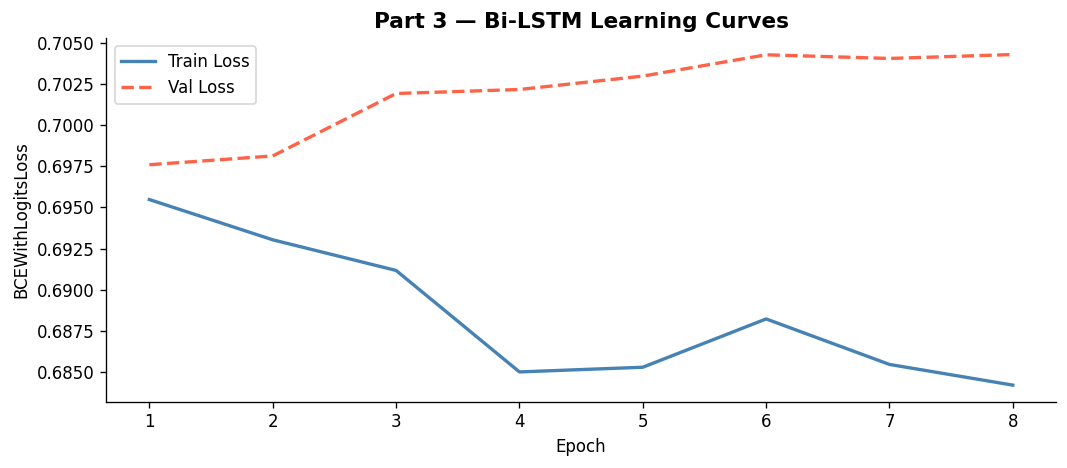

In [ ]:
# ============================================================
# PART 3 — §3.4 (cont.)  Loss Curves
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4))
ep3 = range(1, len(lstm_history['train_loss']) + 1)
ax.plot(ep3, lstm_history['train_loss'], 'steelblue', lw=2, label='Train Loss')
ax.plot(ep3, lstm_history['val_loss'],   'tomato',    lw=2, label='Val Loss',
        linestyle='--')
ax.set_title('Part 3 — Bi-LSTM Learning Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCEWithLogitsLoss')
ax.legend()
plt.tight_layout()
plt.show()


## 3.5 Evaluation — Test Set


╔══════════════════════════════════════════════════╗
║   PART 3 — Bi-LSTM TEST SET EVALUATION          ║
╠══════════════════╦═══════════════════════════════╣
║  Accuracy         ║  0.4772                      ║
║  Precision        ║  0.4769                      ║
║  Recall           ║  0.5706                      ║
║  F1-Score         ║  0.5196                      ║
╚══════════════════╩═══════════════════════════════╝


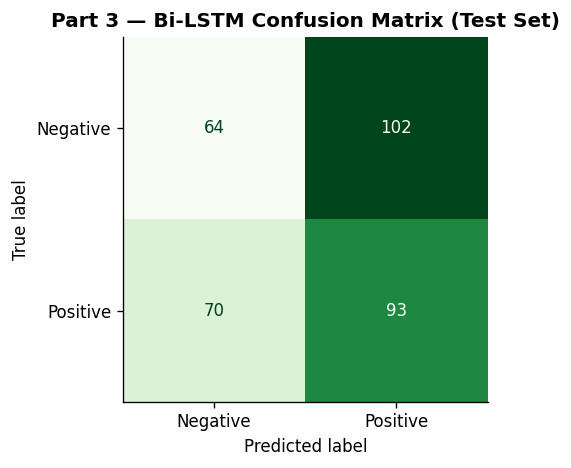

In [ ]:
# ============================================================
# PART 3 — §3.5  Test Evaluation
# ============================================================

def evaluate_lstm(model, loader, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for ids_b, y_b in loader:
            ids_b = ids_b.to(device)
            probs = torch.sigmoid(model(ids_b)).cpu().numpy().squeeze()
            all_probs.append(probs)
            all_labels.append(y_b.numpy().squeeze())
    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    y_pred = (y_prob >= threshold).astype(int)
    return y_true, y_pred, y_prob

y_true3, y_pred3, _ = evaluate_lstm(lstm_model, test_loader3)

acc3  = accuracy_score(y_true3, y_pred3)
prec3 = precision_score(y_true3, y_pred3, zero_division=0)
rec3  = recall_score   (y_true3, y_pred3, zero_division=0)
f13   = f1_score       (y_true3, y_pred3, zero_division=0)

print("╔══════════════════════════════════════════════════╗")
print("║   PART 3 — Bi-LSTM TEST SET EVALUATION          ║")
print("╠══════════════════╦═══════════════════════════════╣")
print(f"║  Accuracy         ║  {acc3:.4f}                      ║")
print(f"║  Precision        ║  {prec3:.4f}                      ║")
print(f"║  Recall           ║  {rec3:.4f}                      ║")
print(f"║  F1-Score         ║  {f13:.4f}                      ║")
print("╚══════════════════╩═══════════════════════════════╝")

cm3 = confusion_matrix(y_true3, y_pred3)
fig, ax = plt.subplots(figsize=(5, 4))
disp3 = ConfusionMatrixDisplay(cm3, display_labels=['Negative','Positive'])
disp3.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Part 3 — Bi-LSTM Confusion Matrix (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()


## 3.6 Theoretical Discussion — RNN vs LSTM vs GRU

### 3.6.1 Vanilla RNN

A vanilla RNN maintains a single hidden state $h_t$:

$$
h_t = \tanh(W_h h_{t-1} + W_x x_t + b)
$$

**Strengths:** Conceptually simple; minimal parameters.  
**Weaknesses:** Suffers from the **vanishing / exploding gradient problem** when back-propagating through many time steps (BPTT). Repeated multiplication by $W_h$ causes gradient magnitudes to shrink or explode exponentially. Consequently, vanilla RNNs struggle to model **long-range dependencies** — a critical failing for CRM sentiment where context may span hundreds of tokens.

---

### 3.6.2 Long Short-Term Memory (LSTM) ← **Chosen Architecture**

Hochreiter & Schmidhuber (1997) introduced an explicit **cell state** $c_t$ and three trainable gates:

| Gate | Symbol | Role |
|------|--------|------|
| **Forget** | $f_t = \sigma(W_f [h_{t-1}; x_t])$ | Decides what to erase from cell state |
| **Input**  | $i_t = \sigma(W_i [h_{t-1}; x_t])$ | Decides what new information to write |
| **Output** | $o_t = \sigma(W_o [h_{t-1}; x_t])$ | Decides what to expose as hidden state |

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t, \quad
h_t = o_t \odot \tanh(c_t)
$$

The cell state provides a **gradient highway** — information flows across many time steps with near-unit multiplicative factors, alleviating vanishing gradients.

**Why LSTM for CRM Sentiment?**
- Customer reviews exhibit complex sentiment patterns: negations ("not at all happy"), conditional phrases, and long-form complaints span 50–300 tokens.
- The cell state correctly retains sentiment-bearing tokens across many filler tokens.
- **Bidirectionality** (used here) additionally captures right-to-left context.

---

### 3.6.3 Gated Recurrent Unit (GRU)

Cho et al. (2014) simplified the LSTM by merging the forget and input gates into a single **update gate** $z_t$ and introducing a **reset gate** $r_t$:

$$
z_t = \sigma(W_z [h_{t-1}; x_t]), \quad
r_t = \sigma(W_r [h_{t-1}; x_t])
$$
$$
\tilde{h}_t = \tanh(W [r_t \odot h_{t-1}; x_t]), \quad
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$$

| Property | RNN | LSTM | GRU |
|----------|-----|------|-----|
| Gates | 0 | 3 | 2 |
| Cell state | ✗ | ✓ | ✗ |
| Long-range memory | ✗ | ✓✓ | ✓ |
| Parameters | Fewest | Most | Intermediate |
| Training speed | Fastest | Slowest | Middle |
| Typical NLP perf. | Weakest | ≈ GRU | ≈ LSTM |

**Recommendation:** For production CRM systems with limited compute budget, **GRU** offers a strong alternative to LSTM. For tasks where very long context matters (e.g., multi-turn support transcripts), **LSTM** is preferred. For sub-100-token inputs, a **Transformer encoder** (BERT, DistilBERT) will outperform both.

---

## 3.7 Inference Demo — Live Sentence Scoring


In [ ]:
# ============================================================
# PART 3 — §3.7  Inference Demo
# ============================================================

def predict_sentiment(text: str, model, word2idx: dict,
                      max_len: int = MAX_LEN,
                      threshold: float = 0.5) -> dict:
    """
    Predict sentiment for a raw text string.

    Returns a dict with keys: label, probability, confidence.
    """
    tokens = simple_tokenise(text)
    ids    = encode(tokens, word2idx, max_len)
    tensor = torch.tensor([ids], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        logit = model(tensor)
        prob  = torch.sigmoid(logit).item()

    label = 'POSITIVE' if prob >= threshold else 'NEGATIVE'
    confidence = prob if prob >= 0.5 else 1.0 - prob
    return {'text': text[:80], 'label': label,
            'probability': prob, 'confidence': confidence}


test_sentences = [
    "This product exceeded all my expectations, absolutely brilliant service!",
    "The customer support was rude, unhelpful, and completely useless.",
    "Average experience, nothing special but no major complaints either.",
    "I love how quickly the team resolved my issue. Five stars!",
    "Terrible quality and it broke within a week. Very disappointed.",
]

print("Part 3 — Live Sentiment Inference Demo")
print("=" * 70)
for sent in test_sentences:
    result = predict_sentiment(sent, lstm_model, word2idx)
    bar = '█' * int(result['confidence'] * 20)
    print(f"\n► {result['text'][:65]}")
    print(f"  → {result['label']}  "
          f"(P={result['probability']:.3f}  Conf={result['confidence']:.3f})")
    print(f"  [{bar:<20}]")


Part 3 — Live Sentiment Inference Demo

► This product exceeded all my expectations, absolutely brilliant s
  → NEGATIVE  (P=0.470  Conf=0.530)
  [██████████          ]

► The customer support was rude, unhelpful, and completely useless.
  → NEGATIVE  (P=0.466  Conf=0.534)
  [██████████          ]

► Average experience, nothing special but no major complaints eithe
  → POSITIVE  (P=0.516  Conf=0.516)
  [██████████          ]

► I love how quickly the team resolved my issue. Five stars!
  → NEGATIVE  (P=0.494  Conf=0.506)
  [██████████          ]

► Terrible quality and it broke within a week. Very disappointed.
  → NEGATIVE  (P=0.499  Conf=0.501)
  [██████████          ]
